In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("spam_email.csv", sep='\t', names=['label','message'])
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    words = word_tokenize(text)
    words = [ps.stem(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df['message'] = df['message'].apply(clean_text)

print(df.head())

   label                                            message
0      0  jurong point crazi avail bugi great world buff...
1      0                                   lar joke wif oni
2      1  free entri wkli comp win cup final tkt 21st ma...
3      0                      dun say earli hor alreadi say
4      0          nah dont think goe usf live around though


In [3]:
spam_keywords = ['free','win','winner','prize','claim','urgent','call','offer','click','buy','congratulations','ticket']
ham_keywords = ['hey','hello','meet','tomorrow','thanks','please','talk','later']

def count_spam_words(text):
    return sum(1 for word in spam_keywords if word in text)

def count_ham_words(text):
    return sum(1 for word in ham_keywords if word in text)

df['spam_word_count'] = df['message'].apply(count_spam_words)
df['ham_word_count'] = df['message'].apply(count_ham_words)

# Ratio
df['spam_score'] = df['spam_word_count'] / (df['ham_word_count'] + 1)

# Extra features
df['length'] = df['message'].apply(len)
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['has_link'] = df['message'].apply(lambda x: 1 if 'http' in x or 'www' in x else 0)
df['exclaim_count'] = df['message'].apply(lambda x: x.count('!'))

print(df.head())

   label                                            message  spam_word_count  \
0      0  jurong point crazi avail bugi great world buff...                0   
1      0                                   lar joke wif oni                0   
2      1  free entri wkli comp win cup final tkt 21st ma...                2   
3      0                      dun say earli hor alreadi say                0   
4      0          nah dont think goe usf live around though                0   

   ham_word_count  spam_score  length  digit_count  word_count  has_link  \
0               0         0.0      66            0          12         0   
1               0         0.0      16            0           4         0   
2               0         2.0     123           24          20         0   
3               0         0.0      29            0           6         0   
4               0         0.0      41            0           8         0   

   exclaim_count  
0              0  
1              0  
2    

Logistic Regression: 0.9847533632286996
SVM: 0.9883408071748879
Final Model: SVM
Confusion Matrix:
 [[961   5]
 [  8 141]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



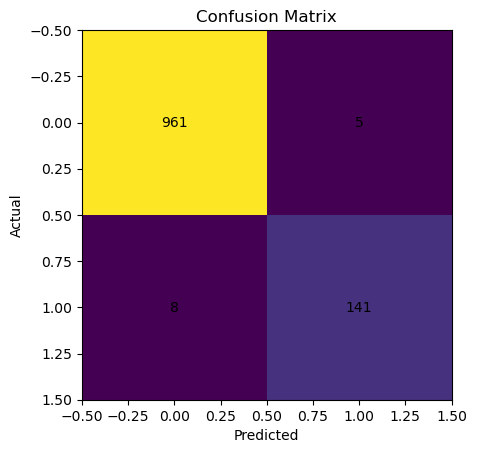

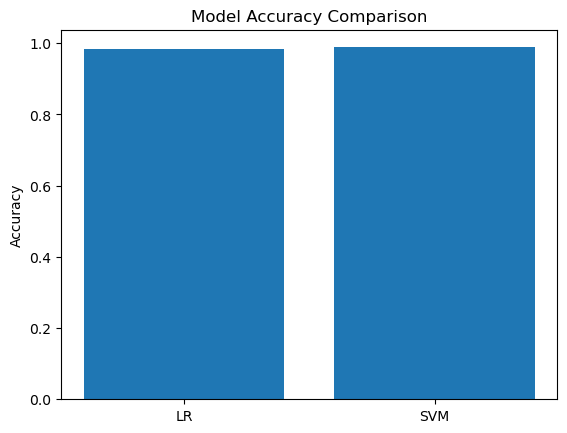

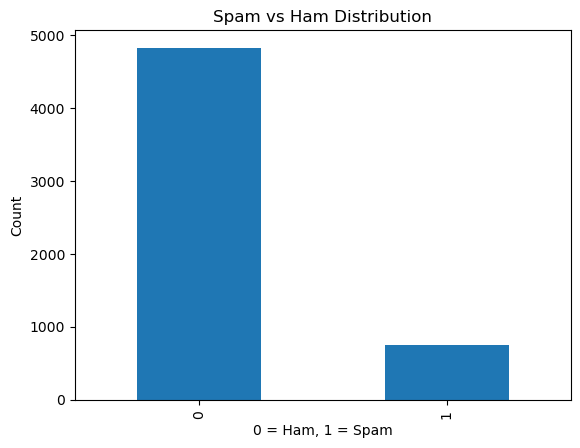

In [4]:
X = df['message']
y = df['label']


tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)


from scipy.sparse import hstack

extra_features = np.array(df[
    ['spam_word_count','ham_word_count','spam_score',
     'length','digit_count','word_count','has_link','exclaim_count']
])

X_combined = hstack([X_tfidf, extra_features])


X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)


lr = LogisticRegression(max_iter=1000, class_weight='balanced')
svm = SVC(kernel='linear', class_weight='balanced')

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)


lr_acc = accuracy_score(y_test, lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))

print("Logistic Regression:", lr_acc)
print("SVM:", svm_acc)


if lr_acc > svm_acc:
    final_model = lr
    print("Final Model: Logistic Regression")
else:
    final_model = svm
    print("Final Model: SVM")


y_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()


models = ['LR','SVM']
accuracy = [lr_acc, svm_acc]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("0 = Ham, 1 = Spam")
plt.ylabel("Count")
plt.show()

In [5]:
def predict_spam(text):
    clean = clean_text(text)
    
    spam_count = count_spam_words(clean)
    ham_count = count_ham_words(clean)
    score = spam_count / (ham_count + 1)
    
    length = len(clean)
    digit_count = sum(c.isdigit() for c in clean)
    word_count = len(clean.split())
    has_link = 1 if 'http' in text or 'www' in text else 0
    exclaim_count = text.count('!')
    
    vec = tfidf.transform([clean])
    
    from scipy.sparse import hstack
    vec = hstack([vec, np.array([[spam_count, ham_count, score,
                                  length, digit_count, word_count,
                                  has_link, exclaim_count]])])
    
    result = final_model.predict(vec)[0]

    
    if spam_count >= 3:
        return "Spam (High Confidence)"
    elif score > 1.2:
        return "Likely Spam"
    elif has_link == 1:
        return "Spam (Contains Link)"
    elif result == 1:
        return "Possible Spam"
    else:
        return "Not Spam"

# ================= TEST =================
print(predict_spam("hey bro won free ticket grafest call tomorrow"))
print(predict_spam("Hey let's meet tomorrow"))
print(predict_spam("Congratulations! You won a free ticket"))
print(predict_spam("Call now to claim your prize"))

Spam (High Confidence)
Not Spam
Likely Spam
Spam (High Confidence)
